### Prepare Data 📝

##### Merge Dataset 🔂

In [228]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
plt.style.use("ggplot")

Dataframe

In [229]:
# Carmell Directory
# links_df = pd.read_csv(r"C:\coding\Data Mining\Movie-Recommendation-System\Data\ml-latest-small\links.csv")
# movies_df = pd.read_csv(r"C:\coding\Data Mining\Movie-Recommendation-System\Data\ml-latest-small\movies.csv")
# ratings_df = pd.read_csv(r"C:\coding\Data Mining\Movie-Recommendation-System\Data\ml-latest-small\ratings.csv").sort_values(by=["userId"])
# tags_df = pd.read_csv(r"C:\coding\Data Mining\Movie-Recommendation-System\Data\ml-latest-small\tags.csv").sort_values(by=["userId"])

# Wormy Directory
links_df = pd.read_csv(r"D:\Python Course\Movie Recommendation System\Data\ml-latest-small\links.csv")
movies_df = pd.read_csv(r"D:\Python Course\Movie Recommendation System\Data\ml-latest-small\movies.csv")
ratings_df = pd.read_csv(r"D:\Python Course\Movie Recommendation System\Data\ml-latest-small\ratings.csv").sort_values(by=["userId"])
tags_df = pd.read_csv(r"D:\Python Course\Movie Recommendation System\Data\ml-latest-small\tags.csv").sort_values(by=["userId"])

In [230]:
links_df.head()

,movieId,imdbId,tmdbId
0,1,114709,862.0
1,2,113497,8844.0
2,3,113228,15602.0
3,4,114885,31357.0
4,5,113041,11862.0


In [231]:
movies_df.head()

,movieId,title,genres
0,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy
1,2,Jumanji (1995),Adventure|Children|Fantasy
2,3,Grumpier Old Men (1995),Comedy|Romance
3,4,Waiting to Exhale (1995),Comedy|Drama|Romance
4,5,Father of the Bride Part II (1995),Comedy


In [232]:
ratings_df.head()

,userId,movieId,rating,timestamp
180,1,2716,5.0,964983414
181,1,2761,5.0,964982703
182,1,2797,4.0,964981710
183,1,2826,4.0,964980523
184,1,2858,5.0,964980868


In [233]:
tags_df.head()

,userId,movieId,tag,timestamp
0,2,60756,funny,1445714994
1,2,60756,Highly quotable,1445714996
2,2,60756,will ferrell,1445714992
8,2,106782,Martin Scorsese,1445715056
6,2,106782,drugs,1445715054


Merge Dataframes

In [234]:
# Merge Data
merge1_df = ratings_df.merge(
    movies_df,
    on="movieId",
    how="left"
).merge(
    tags_df[["movieId", "tag"]],
    on="movieId",
    how="left"
).merge(
    links_df,
    on="movieId",
    how="left"
).dropna(axis=0)

merge1_df.head()

,userId,movieId,rating,timestamp,title,genres,tag,imdbId,tmdbId
0,1,2716,5.0,964983414,Ghostbusters (a.k.a. Ghost Busters) (1984),Action|Comedy|Sci-Fi,ghosts,87332,620.0
1,1,2761,5.0,964982703,"Iron Giant, The (1999)",Adventure|Animation|Children|Drama|Sci-Fi,robots,129167,10386.0
2,1,2761,5.0,964982703,"Iron Giant, The (1999)",Adventure|Animation|Children|Drama|Sci-Fi,animation,129167,10386.0
3,1,2797,4.0,964981710,Big (1988),Comedy|Drama|Fantasy|Romance,children,94737,2280.0
6,1,2872,5.0,964981680,Excalibur (1981),Adventure|Fantasy,England,82348,11527.0


In [235]:
movieLens_df = merge1_df[["userId", "movieId", "title", "genres",
                          "tag", "rating", "imdbId", "tmdbId"]]
movieLens_df.head()

,userId,movieId,title,genres,tag,rating,imdbId,tmdbId
0,1,2716,Ghostbusters (a.k.a. Ghost Busters) (1984),Action|Comedy|Sci-Fi,ghosts,5.0,87332,620.0
1,1,2761,"Iron Giant, The (1999)",Adventure|Animation|Children|Drama|Sci-Fi,robots,5.0,129167,10386.0
2,1,2761,"Iron Giant, The (1999)",Adventure|Animation|Children|Drama|Sci-Fi,animation,5.0,129167,10386.0
3,1,2797,Big (1988),Comedy|Drama|Fantasy|Romance,children,4.0,94737,2280.0
6,1,2872,Excalibur (1981),Adventure|Fantasy,England,5.0,82348,11527.0


### EDA MovieLens Dataframe

##### Understanding Dataframes Structure

In [236]:
movieLens_df.dtypes

userId       int64
movieId      int64
title       object
genres      object
tag         object
rating     float64
imdbId       int64
tmdbId     float64
dtype: object

In [237]:
movieLens_df[movieLens_df == movieLens_df.duplicated]

,userId,movieId,title,genres,tag,rating,imdbId,tmdbId
0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...
285752,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
285753,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
285754,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
285755,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [238]:
movieLens_df["genres"] = movieLens_df["genres"].str.strip().str.replace("|", ", ", regex=False)
movieLens_df

C:\Users\Diandra\AppData\Local\Temp\ipykernel_17952\3592884746.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  movieLens_df["genres"] = movieLens_df["genres"].str.strip().str.replace("|", ", ", regex=False)


,userId,movieId,title,genres,tag,rating,imdbId,tmdbId
0,1,2716,Ghostbusters (a.k.a. Ghost Busters) (1984),"Action, Comedy, Sci-Fi",ghosts,5.0,87332,620.0
1,1,2761,"Iron Giant, The (1999)","Adventure, Animation, Children, Drama, Sci-Fi",robots,5.0,129167,10386.0
2,1,2761,"Iron Giant, The (1999)","Adventure, Animation, Children, Drama, Sci-Fi",animation,5.0,129167,10386.0
3,1,2797,Big (1988),"Comedy, Drama, Fantasy, Romance",children,4.0,94737,2280.0
6,1,2872,Excalibur (1981),"Adventure, Fantasy",England,5.0,82348,11527.0
...,...,...,...,...,...,...,...,...
285752,610,164179,Arrival (2016),Sci-Fi,smart,5.0,2543164,329865.0
285753,610,164179,Arrival (2016),Sci-Fi,beautiful visuals,5.0,2543164,329865.0
285754,610,164179,Arrival (2016),Sci-Fi,Cerebral,5.0,2543164,329865.0
285755,610,164179,Arrival (2016),Sci-Fi,thought-provoking,5.0,2543164,329865.0


#### 1) Data Overview

In [239]:
DataCols = movieLens_df.columns
DataTypes = movieLens_df.dtypes
TotalUser = movieLens_df["userId"].unique().sum()
TotalMovie = movieLens_df["title"].nunique()
dataOverview = f"Data Columns: {DataCols}\nTotal User: {TotalUser}\nTotal Movie: {TotalMovie}\nData Types:\n{DataTypes}"

print(dataOverview)

Data Columns: Index(['userId', 'movieId', 'title', 'genres', 'tag', 'rating', 'imdbId',
       'tmdbId'],
      dtype='object')
Total User: 186355
Total Movie: 1554
Data Types:
userId       int64
movieId      int64
title       object
genres      object
tag         object
rating     float64
imdbId       int64
tmdbId     float64
dtype: object


There are 186k+ users and 1554 movies recorded in this dataset. There are no duplicates nor missing data, the dataset handled well.

#### 2) Rating Distribution Analysis

In [240]:
medRat = movieLens_df["rating"].median()
avgRat = movieLens_df["rating"].mean()
mostRat = movieLens_df["rating"].value_counts().idxmax()
leastRat = movieLens_df["rating"].value_counts().idxmin()

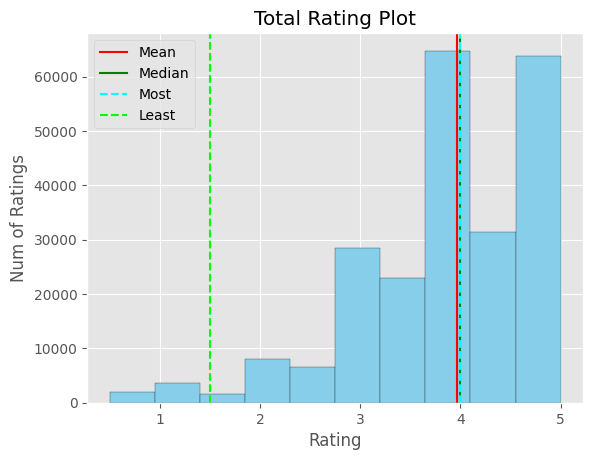

In [251]:
# Rating Plot
plt.hist(movieLens_df["rating"], color="skyblue", linewidth=0.2, edgecolor="black")
plt.axvline(avgRat, color="red", label="Mean")
plt.axvline(medRat, color="green", label="Median")
plt.axvline(mostRat, color="cyan", label="Most", linestyle="--")
plt.axvline(leastRat, color="lime", label="Least", linestyle="--")
plt.title("Total Rating Plot")
plt.xlabel("Rating")
plt.ylabel("Num of Ratings")
plt.legend()

As we can see from those 2 plots, the data tend to be skewed to the right although not in a perfect shape. The low ratings data especially with a rate below 3 are quite rare. From the plot we know, most of the ratings data are on 3-5 range. In summary we know most of the users are tend to give high ratings.

#### 3) User Activity Analysis

In [ ]:
numRateUser = movieLens_df.groupby("userId")["rating"].count().sort_values(ascending=False)
mostActiveUsr = movieLens_df.groupby("userId")["rating"].count().idxmax()
leastActiveUsr = movieLens_df.groupby("userId")["rating"].count().idxmin()
print(f"Number of rate per user:\n{numRateUser}\nMost active user with id of: {mostActiveUsr}\nLeast active user with id of: {leastActiveUsr}")

Number of rate per user:
userId
474    2455
414    2343
599    2100
68     1791
610    1701
       ... 
406      10
499       9
207       8
578       6
175       5
Name: rating, Length: 610, dtype: int64
Most active user with id of: 474
Least active user with id of: 175


Most of the user rate a movie more than once. The most user give a rate is user by id of 474, rates movies 2455 times. While the least user give a rate of movie is user by id of 175 only rates a movies 5 times.

#### 4) Movie Popularity Analysis

In [313]:
numRateMovie = movieLens_df.groupby("title")["rating"].count().sort_values(ascending=False)
avgRateMovie = movieLens_df.groupby("title")["rating"].mean()
mostRateMovie = movieLens_df.groupby("title")["rating"].count().idxmax()
leastRateMovie = movieLens_df.groupby("title")["rating"].count().idxmin()

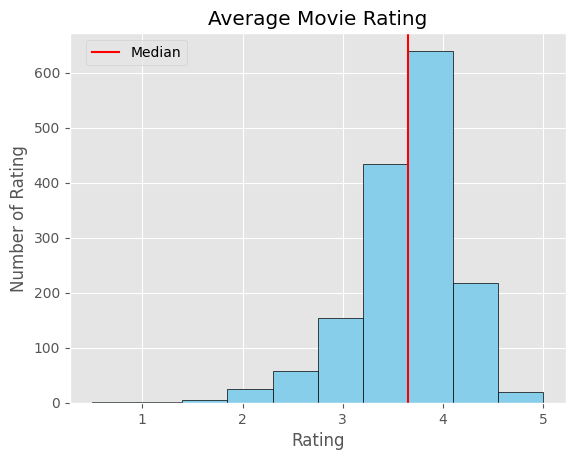

In [310]:
# Average Movie Rating 
plt.hist(avgRateMovie, color="skyblue", edgecolor="black", linewidth=0.5)
plt.axvline(avgRateMovie.mean(), color="red", label="Median")
plt.title("Average Movie Rating")
plt.xlabel("Rating")
plt.ylabel("Number of Rating")
plt.legend(bbox_to_anchor=(0.25, 1))

In [315]:
print(f"Number of rating per movie:\n{numRateMovie}")

Number of rating per movie:
title
Pulp Fiction (1994)                                               55567
Fight Club (1999)                                                 11772
Star Wars: Episode IV - A New Hope (1977)                          6526
Léon: The Professional (a.k.a. The Professional) (Léon) (1994)     4655
2001: A Space Odyssey (1968)                                       4469
                                                                  ...  
Waco: The Rules of Engagement (1997)                                  1
Wit (2001)                                                            1
Avalon (1990)                                                         1
Woman Under the Influence, A (1974)                                   1
Alice Adams (1935)                                                    1
Name: rating, Length: 1554, dtype: int64


In [324]:
print(f"Average rating per movie:\t{avgRateMovie}\nMost rated movie: {mostRateMovie}\nLeast rated movie: {leastRateMovie}\n")

Average rating per movie:	title
(500) Days of Summer (2009)          3.666667
...And Justice for All (1979)        3.166667
10 Cloverfield Lane (2016)           3.678571
10 Things I Hate About You (1999)    3.527778
101 Dalmatians (1996)                3.074468
                                       ...   
Zero Dark Thirty (2012)              4.107143
Zombieland (2009)                    3.877358
Zoolander (2001)                     3.509259
Zulu (1964)                          4.000000
eXistenZ (1999)                      3.863636
Name: rating, Length: 1554, dtype: float64
Most rated movie: Pulp Fiction (1994)
Least rated movie: Alice Adams (1935)



From the data above, we know the Pulp Fiction (1994) is the most rated movie and dominates the field. It's rated 55567 times, while the least rated movie given to Alice Adams (1935) with number of rate 1, however Alice Adams is not the only movie has once rated, however we picked Alice Adams because it is the oldest in least rated movie. Futhermore, as we can see from the data, there's a lot unpopular movies with high rated.